# 08 — Runtime Engine Verification & Paired Metrics

Notebook này đọc **engineering smoke outputs** đã sinh bởi DES engine thực tế.

> Các output hiện tại dùng `haversine_smoke_test`, nên chỉ chứng minh pipeline chạy đúng về mặt phần mềm/invariant. Không dùng các số này làm kết quả khoa học cuối cùng.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

cwd=Path.cwd().resolve()
ROOT=next((p for p in [cwd,cwd.parent,*cwd.parents] if (p/'experiments'/'smoke_3rep').exists()),None)
if ROOT is None: raise FileNotFoundError('Không tìm thấy experiments/smoke_3rep')
EXP=ROOT/'experiments'/'smoke_3rep'
metrics=pd.read_csv(EXP/'replication_metrics.csv')
validation=json.loads((EXP/'runtime_validation.json').read_text())
print('ROOT=',ROOT)
print('rows=',len(metrics))
validation

ROOT= /mnt/data/eambulance_full_pipeline
rows= 36


{'all_pass': True,
 'checks_passed': 7,
 'checks_total': 7,
 'checks': [{'check': 'common_random_pairing',
   'passed': True,
   'detail': [{'scenario_id': 'high_demand',
     'replication_id': 'R001',
     'policy_count': 4,
     'seed_count': 1,
     'group_count': 1},
    {'scenario_id': 'high_demand',
     'replication_id': 'R002',
     'policy_count': 4,
     'seed_count': 1,
     'group_count': 1},
    {'scenario_id': 'high_demand',
     'replication_id': 'R003',
     'policy_count': 4,
     'seed_count': 1,
     'group_count': 1},
    {'scenario_id': 'normal',
     'replication_id': 'R001',
     'policy_count': 4,
     'seed_count': 1,
     'group_count': 1},
    {'scenario_id': 'normal',
     'replication_id': 'R002',
     'policy_count': 4,
     'seed_count': 1,
     'group_count': 1}]},
  {'check': 'metrics_count_matches_completed_runs',
   'passed': True,
   'detail': '36/36'},
  {'check': '100_incident_rows_per_run', 'passed': True, 'detail': []},
  {'check': 'SOC_bounds_0_

## 1. Pair completeness

In [2]:
pair=(metrics.groupby(['scenario_id','replication_id'])
      .agg(policy_count=('policy_id','nunique'),seed_count=('random_seed','nunique'),group_count=('common_random_group','nunique'))
      .reset_index())
pair['complete']=(pair.policy_count==4)&(pair.seed_count==1)&(pair.group_count==1)
pair

,scenario_id,replication_id,policy_count,seed_count,group_count,complete
0,high_demand,R001,4,1,1,True
1,high_demand,R002,4,1,1,True
2,high_demand,R003,4,1,1,True
3,normal,R001,4,1,1,True
4,normal,R002,4,1,1,True
5,normal,R003,4,1,1,True
6,peak,R001,4,1,1,True
7,peak,R002,4,1,1,True
8,peak,R003,4,1,1,True


## 2. Mean metric by policy — smoke only

In [3]:
show=['served_rate','feasible_rate_overall','SLA_pass_rate','avg_response_time_min','P95_response_P1']
display(metrics.groupby(['scenario_id','policy_id'])[show].mean().round(3))

served_rate  ...  P95_response_P1
scenario_id policy_id               ...                 
high_demand B0               0.980  ...           13.098
            B3               0.867  ...           14.467
            B4               0.863  ...           14.472
            B6               0.860  ...           15.319
normal      B0               0.963  ...           14.149
            B3               0.960  ...           13.856
            B4               0.960  ...           13.572
            B6               0.957  ...           14.898
peak        B0               0.970  ...           13.240
            B3               0.927  ...           14.451
            B4               0.930  ...           14.451
            B6               0.920  ...           14.984

[12 rows x 5 columns]

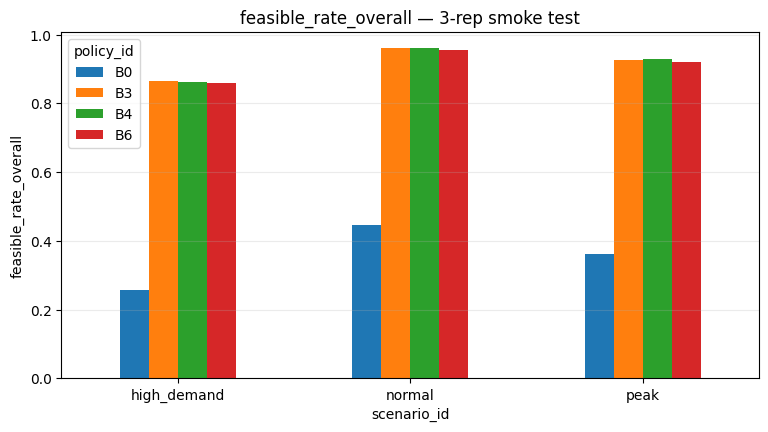

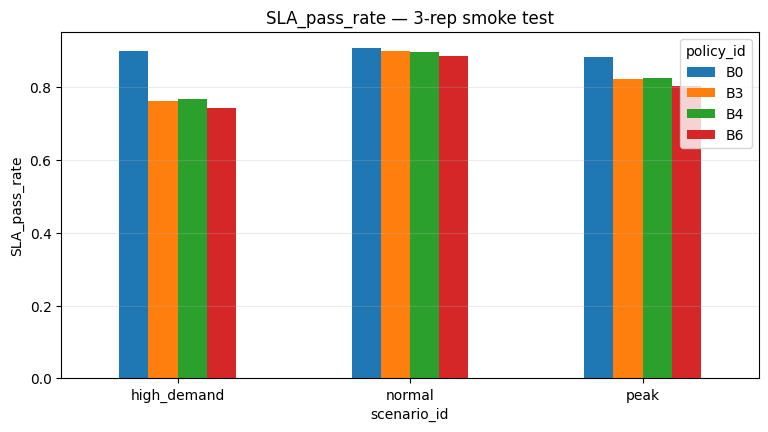

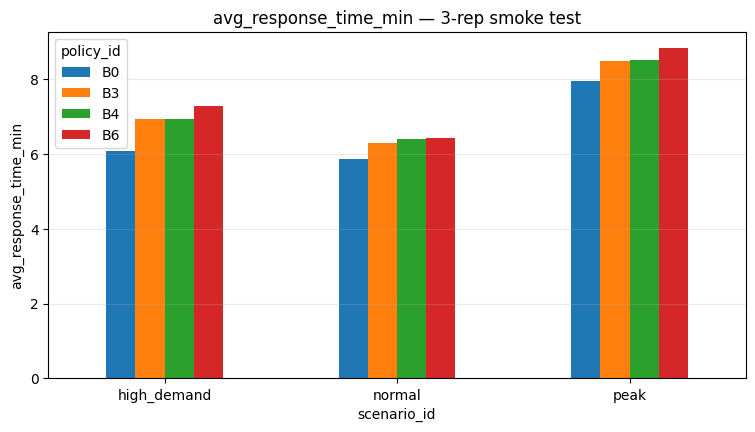

In [4]:
for metric in ['feasible_rate_overall','SLA_pass_rate','avg_response_time_min']:
    pivot=metrics.pivot_table(index='scenario_id',columns='policy_id',values=metric,aggfunc='mean')
    ax=pivot.plot(kind='bar',figsize=(9,4.5),title=f'{metric} — 3-rep smoke test')
    ax.set_ylabel(metric)
    ax.grid(axis='y',alpha=.25)
    plt.xticks(rotation=0)
    plt.show()

## 3. B6 solver diagnostics

In [5]:
b6=metrics[metrics.policy_id=='B6']
display(b6[['scenario_id','replication_id','avg_solver_time_sec','max_mip_gap','b6_epsilon_relaxation_count','routing_source']])
print('Mean B6 solver time/epoch:',b6.avg_solver_time_sec.mean())
print('Max MIP gap:',b6.max_mip_gap.max())
print('Total epsilon relaxations:',b6.b6_epsilon_relaxation_count.sum())

,scenario_id,replication_id,avg_solver_time_sec,max_mip_gap,b6_epsilon_relaxation_count,routing_source
3,normal,R001,0.005248,0.0,0,haversine_smoke_test
7,normal,R002,0.001632,0.0,0,haversine_smoke_test
11,normal,R003,0.001621,0.0,0,haversine_smoke_test
15,peak,R001,0.001593,0.0,0,haversine_smoke_test
19,peak,R002,0.001500,0.0,0,haversine_smoke_test
23,peak,R003,0.001404,0.0,0,haversine_smoke_test
27,high_demand,R001,0.001481,0.0,0,haversine_smoke_test
31,high_demand,R002,0.001476,0.0,0,haversine_smoke_test
35,high_demand,R003,0.001437,0.0,0,haversine_smoke_test


Mean B6 solver time/epoch: 0.001932326893332422
Max MIP gap: 0.0
Total epsilon relaxations: 0


## 4. Runtime invariant audit

In [6]:
pd.DataFrame(validation['checks'])[['check','passed','detail']]

,check,passed,detail
0,common_random_pairing,True,"[{'scenario_id': 'high_demand', 'replication_i..."
1,metrics_count_matches_completed_runs,True,36/36
2,100_incident_rows_per_run,True,[]
3,SOC_bounds_0_100,True,[]
4,policy_hard_constraints,True,[]
5,event_order_monotonic,True,[]
6,charging_completion_SOC_nondecreasing,True,[]


## 5. Final 30-paired command

Chỉ chạy sau khi Notebook 02 đã tạo `data/osmnx/*`:

```bash
./scripts/run_30_paired_osmnx.sh
```

Không thêm `--allow-haversine-fallback` vào experiment cuối.